### Punto 1 — Entender el problema y el target
- **Thyroid Disease (Differentiated Thyroid Cancer Recurrence)**: este dataset reúne variables clínicas, histopatológicas y de estadificación oncológica (edad, género, hábito de fumar, hallazgos físicos, tipo de patología, estadio TNM, respuesta al tratamiento, etc.) de pacientes con cáncer de tiroides diferenciado.
- **Target**: `Recurred` (Sí/No) — si el cáncer reincidió tras el tratamiento. Es una variable categórica binaria → problema de **clasificación binaria**.

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

pd.set_option("display.max_columns", None)

### Punto 2 — Carga y descripción inicial

In [2]:
df = pd.read_csv("data/Thyroid_Diff.csv")
display(df.head())
display(df.tail())
print("Shape:", df.shape)
df.info()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


Shape: (383, 17)
<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response              383 non-null    str  
 16  Re

**Diccionario de datos**

| Columna | Tipo esperado | Significado |
|---|---|---|
| Age | Numérica continua | Edad del paciente en años |
| Gender | Categórica binaria | F / M |
| Smoking | Categórica binaria | Si el paciente fuma actualmente |
| Hx Smoking | Categórica binaria | Historial de tabaquismo previo |
| Hx Radiothreapy | Categórica binaria | Historial de radioterapia previa |
| Thyroid Function | Categórica nominal (5) | Estado funcional de la tiroides (eutiroideo, hiper/hipotiroidismo clínico o subclínico) |
| Physical Examination | Categórica nominal (5) | Hallazgo físico del examen (bocio nodular, difuso, normal) |
| Adenopathy | Categórica nominal (6) | Localización de adenopatías (ganglios) encontradas |
| Pathology | Categórica nominal (4) | Subtipo histopatológico del tumor |
| Focality | Categórica binaria | Uni-Focal / Multi-Focal |
| Risk | Categórica ordinal (3) | Riesgo clínico: Low < Intermediate < High |
| T | Categórica ordinal (7) | Estadio del tumor primario (T1a...T4b) |
| N | Categórica ordinal (3) | Compromiso ganglionar: N0 < N1a < N1b |
| M | Categórica binaria | Metástasis a distancia: M0 (no) / M1 (sí) |
| Stage | Categórica ordinal (5) | Estadio general: I < II < III < IVA < IVB |
| Response | Categórica nominal (4) | Respuesta al tratamiento |
| Recurred | Categórica binaria (**target**) | Si el cáncer reincidió: Yes / No |

### Punto 3 — Estadísticos descriptivos

In [3]:
df.describe(include="all")

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
count,383.000000,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383
unique,NaN,2,2,2,2,5,5,6,4,2,3,7,3,2,5,4,2
top,NaN,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
freq,NaN,312,334,355,376,332,140,277,287,247,249,151,268,365,333,208,275
mean,40.866841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,15.134494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Interpretación (sobre los 383 registros originales, antes de eliminar duplicados):**
- **`Age`** —la única variable numérica del dataset— tiene una **media de 40.87 años y una mediana de 37**, con **desviación estándar de 15.13** y un rango de **15 a 82 años**. Que la media supere a la mediana en casi 4 años indica una ligera asimetría hacia la derecha: la población es predominantemente joven-adulta (el 50% central está entre 29 y 51 años) con una cola de pacientes mayores. Clínicamente es coherente con la epidemiología del cáncer de tiroides diferenciado, que se diagnostica a edades más tempranas que la mayoría de los cánceres sólidos.
- **`Recurred`** (target) muestra `No` como categoría más frecuente con **275 de 383 casos (71.8%)**, es decir, un **desbalance de aproximadamente 72/28**. Es una buena noticia clínica —la mayoría de los tratamientos son exitosos— pero una advertencia metodológica: un clasificador trivial que prediga siempre "No" alcanzaría un 72% de Accuracy sin detectar ni un solo caso de recurrencia. Por eso el Punto 19 prioriza Recall y F1 sobre Accuracy, y el Punto 11 usa `stratify`.
- **`Thyroid Function`** tiene `Euthyroid` (función tiroidea normal) como valor dominante con **332 de 383 casos (86.7%)**, y **`M`** (metástasis a distancia) es `M0` en **365 de 383 (95.3%)**. Ambas son variables muy poco informativas por sí solas: casi no varían entre pacientes. Esto anticipa que la capacidad predictiva no vendrá de ellas sino de las variables de estadificación y de respuesta al tratamiento, algo que el Punto 28 confirma con las importancias del modelo.
- **Nota sobre cardinalidad:** `Adenopathy` (6 categorías) y `T` (7 categorías) frente a solo 383 filas implica que varias categorías quedarán con muy pocas observaciones — se cuantifica en el Punto 7 y se maneja con `handle_unknown="ignore"` en el One-Hot Encoder del Punto 12.

### Punto 4 — Valores nulos

In [4]:
df = df.replace("?", pd.NA)
nulos = df.isnull().sum()
porcentaje = (nulos / len(df)) * 100
pd.DataFrame({"nulos": nulos, "%": porcentaje}).sort_values("%", ascending=False)

,nulos,%
Age,0,0.0
Gender,0,0.0
Smoking,0,0.0
Hx Smoking,0,0.0
Hx Radiothreapy,0,0.0
Thyroid Function,0,0.0
Physical Examination,0,0.0
Adenopathy,0,0.0
Pathology,0,0.0
Focality,0,0.0


**Justificación:** este dataset de recurrencia de cáncer **no presenta nulos** en ninguna columna.

### Punto 5 — Duplicados

In [5]:
dup = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Se eliminaron {dup} duplicados")

Se eliminaron 19 duplicados


**Justificación:** se encontraron y eliminaron **19 filas duplicadas** sobre 383 registros totales (~5%). El dataset no incluye un identificador único de paciente, y varias de sus columnas son categóricas con pocas categorías posibles (ej. `Risk` con 3 valores, `Focality` con 2, `M` con 2); esto hace estadísticamente plausible que distintos pacientes con perfiles clínicos similares (misma edad, mismo estadio, mismo resultado) generen filas idénticas por coincidencia, sin que eso implique necesariamente un error de captura. Aun así, se decide eliminarlas: al no existir una columna que distinga a estos pacientes como individuos distintos, mantener filas exactamente iguales solo añadiría peso repetido a esas combinaciones de variables durante el entrenamiento, sesgando el modelo hacia esos perfiles sin aportar información real nueva.

### Punto 6 — Inconsistencias de formato en categóricas

In [6]:
cat_cols_all = df.columns.drop("Age")
for col in cat_cols_all:
    print(col, "->", sorted(df[col].unique().tolist()))

Gender -> ['F', 'M']
Smoking -> ['No', 'Yes']
Hx Smoking -> ['No', 'Yes']
Hx Radiothreapy -> ['No', 'Yes']
Thyroid Function -> ['Clinical Hyperthyroidism', 'Clinical Hypothyroidism', 'Euthyroid', 'Subclinical Hyperthyroidism', 'Subclinical Hypothyroidism']
Physical Examination -> ['Diffuse goiter', 'Multinodular goiter', 'Normal', 'Single nodular goiter-left', 'Single nodular goiter-right']
Adenopathy -> ['Bilateral', 'Extensive', 'Left', 'No', 'Posterior', 'Right']
Pathology -> ['Follicular', 'Hurthel cell', 'Micropapillary', 'Papillary']
Focality -> ['Multi-Focal', 'Uni-Focal']
Risk -> ['High', 'Intermediate', 'Low']
T -> ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b']
N -> ['N0', 'N1a', 'N1b']
M -> ['M0', 'M1']
Stage -> ['I', 'II', 'III', 'IVA', 'IVB']
Response -> ['Biochemical Incomplete', 'Excellent', 'Indeterminate', 'Structural Incomplete']
Recurred -> ['No', 'Yes']


**Conclusión:** al revisar los valores únicos de todas las columnas categóricas, se confirma que **no existen inconsistencias de formato** (no hay mezcla de mayúsculas/minúsculas, espacios en blanco al inicio/final, ni etiquetas equivalentes escritas de forma distinta, como "yes"/"Yes"/"YES"). Por lo tanto, no se requiere ninguna corrección de texto en esta fase; el dataset llega ya estandarizado en cuanto a formato categórico.

### Punto 7 — Outliers (criterio IQR)

In [7]:
# Age es la única variable numérica continua del dataset
Q1, Q3 = df["Age"].quantile(0.25), df["Age"].quantile(0.75)
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_age = df[(df["Age"] < lim_inf) | (df["Age"] > lim_sup)]
print("Outliers en Age:", len(outliers_age))

# Como el resto de variables son categóricas, se revisa el análogo: categorías con muy baja frecuencia
for col in ["Adenopathy", "T", "Pathology"]:
    freq = df[col].value_counts(normalize=True) * 100
    print(f"\n{col}:")
    print(freq[freq < 5])  # categorías presentes en menos del 5% de los casos

Outliers en Age: 0

Adenopathy:
Adenopathy
Left         4.670330
Extensive    1.923077
Posterior    0.549451
Name: proportion, dtype: float64

T:
T
T3b    4.395604
T4b    2.197802
Name: proportion, dtype: float64

Pathology:
Series([], Name: proportion, dtype: float64)


**Justificación:** el enunciado pide aplicar el criterio IQR sobre **al menos dos columnas numéricas**, pero este dataset tiene **una sola variable numérica** (`Age`); las otras 16 son categóricas. Para cubrir la intención del punto —detectar valores anómalos que puedan distorsionar el modelo— se hacen dos análisis complementarios:

1. **IQR sobre `Age`**: con Q1 = 30, Q3 = 52 e IQR = 22, los límites quedan en \[-3 ; 85\] años. **No hay ningún outlier** (el rango observado es 15–82 años), lo cual es biológicamente esperable: no hay edades imposibles ni errores de captura tipo "edad = 200".
2. **Análogo categórico — categorías de muy baja frecuencia** (<5% de los casos), que en variables categóricas cumplen el papel que los outliers cumplen en las numéricas: `Adenopathy` tiene `Left` (4.7%), `Extensive` (1.9%) y `Posterior` (0.5%); `T` tiene `T3b` (4.4%) y `T4b` (2.2%); `Pathology` no tiene ninguna.

**Decisión: no se eliminan ni se agrupan.** Son presentaciones clínicas reales —una adenopatía extensa o un tumor T4b describen a pacientes que existen y que son precisamente los de mayor riesgo de recurrencia—, no errores. Eliminarlas sesgaría el modelo hacia los casos leves justo en el segmento que más importa detectar. Se documenta, eso sí, un riesgo derivado: con tan pocas observaciones, alguna de estas categorías puede aparecer en validación o test sin haber estado en train. Ese riesgo se neutraliza en el Punto 12 con `OneHotEncoder(handle_unknown="ignore")`, que codifica una categoría nunca vista como un vector de ceros en lugar de lanzar un error.

### Punto 8 — Gráficas de EDA

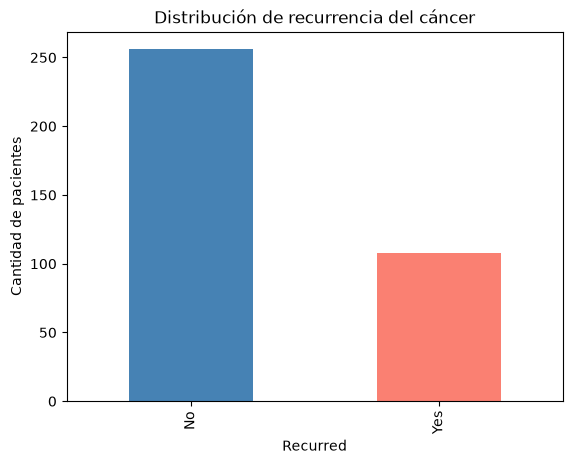

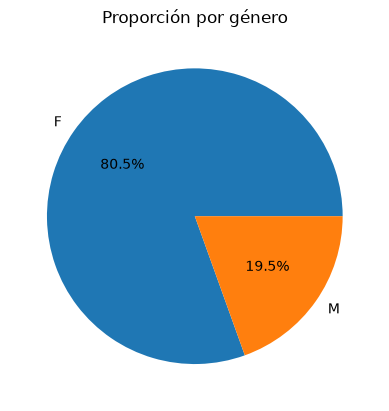

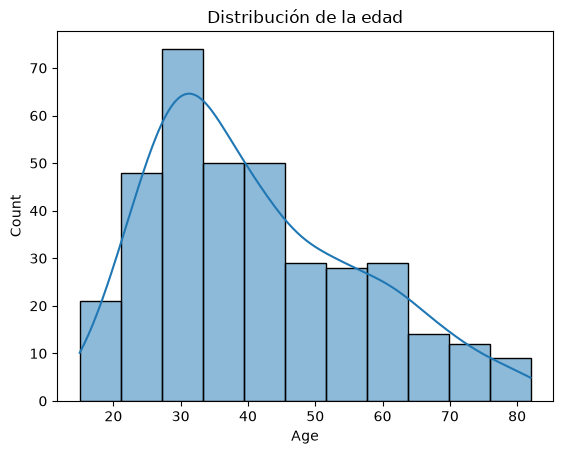

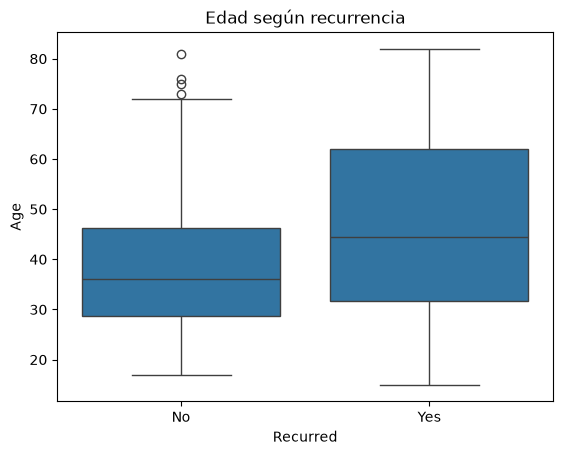

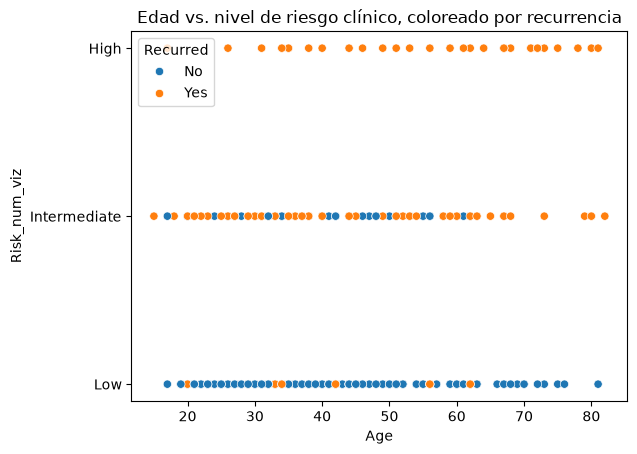

In [8]:
# Barras: distribución del target
df["Recurred"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Distribución de recurrencia del cáncer")
plt.xlabel("Recurred"); plt.ylabel("Cantidad de pacientes")
plt.show()

# Pie: proporción de género
df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Proporción por género")
plt.ylabel("")
plt.show()

# Histograma: distribución de la edad
sns.histplot(df["Age"], kde=True)
plt.title("Distribución de la edad")
plt.show()

# Boxplot: edad según recurrencia
sns.boxplot(x="Recurred", y="Age", data=df)
plt.title("Edad según recurrencia")
plt.show()

# Scatter: como Age es la única variable numérica, se usa Risk codificado ordinalmente solo para visualizar
risk_map = {"Low": 1, "Intermediate": 2, "High": 3}
df["Risk_num_viz"] = df["Risk"].map(risk_map)
sns.scatterplot(x="Age", y="Risk_num_viz", hue="Recurred", data=df)
plt.title("Edad vs. nivel de riesgo clínico, coloreado por recurrencia")
plt.yticks([1, 2, 3], ["Low", "Intermediate", "High"])
plt.show()
df = df.drop(columns=["Risk_num_viz"])  # era solo para graficar

**Interpretación por gráfica** (sobre los 364 registros que quedan tras eliminar duplicados):

- **Barras (distribución de `Recurred`)**: **256 pacientes sin recurrencia (70.3%) frente a 108 con recurrencia (29.7%)**, un desbalance de aproximadamente 70/30. Recomendación: la Accuracy es una métrica engañosa aquí —predecir siempre "No" ya daría 70.3%—, así que la comparación de modelos debe apoyarse en **Recall y F1 de la clase "Yes"**, y los tres splits deben hacerse con `stratify` (Punto 11) para que validación y test conserven esa misma proporción; con solo 108 casos positivos en total, un split no estratificado podría dejar validación con muy pocos.

- **Pie (proporción de `Gender`)**: **293 mujeres (80.5%) y 71 hombres (19.5%)**, consistente con la epidemiología real del cáncer de tiroides diferenciado, que es 3–4 veces más frecuente en mujeres. Pero el dato clínicamente relevante es el opuesto al que sugiere el gráfico por sí solo: **la tasa de recurrencia es del 22.5% en mujeres y del 59.2% en hombres** — los hombres recaen 2.6 veces más pese a ser una quinta parte de la muestra. Recomendación: el género es una variable predictiva genuina y debe conservarse; además, conviene vigilar el desempeño del modelo por separado en el subgrupo masculino, donde hay solo 71 pacientes y la estimación es menos confiable.

- **Histograma (`Age`)**: distribución asimétrica a la derecha, con **media 41.25 y mediana 38 años**, el 50% central entre 30 y 52 años, y una cola que llega hasta los 82. Recomendación: el modelo estará bien informado para pacientes de 30 a 52 años, pero los extremos —adolescentes y mayores de 70— están subrepresentados; sus predicciones deben tomarse con más cautela clínica y no como criterio único de seguimiento.

- **Boxplot (`Age` según `Recurred`)**: los pacientes que recayeron son claramente mayores: **mediana de 44.5 años frente a 36 en los que no recayeron** (medias de 47.1 vs. 38.8, unos **8 años de diferencia**). Las cajas se solapan de forma considerable, así que la edad *inclina* la probabilidad pero no separa los grupos por sí sola. Recomendación: reforzar el seguimiento post-tratamiento en pacientes diagnosticados a mayor edad, sin usar la edad como criterio aislado — hay recurrencias desde los 15 años.

- **Scatter (`Age` vs. `Risk`, coloreado por `Recurred`)**: el patrón es contundente y domina a la edad. La tasa de recurrencia por nivel de riesgo clínico es de **5.2% en "Low" (12 de 230), 62.7% en "Intermediate" (64 de 102) y 100% en "High" (32 de 32)**, y esa separación se mantiene a lo largo de todo el eje de edad. Recomendación: **la estratificación de riesgo que ya realiza el médico es un predictor mucho más fuerte que la edad**, y debe pesar de forma decisiva en el modelo. Nota metodológica: `Risk` se codificó numéricamente **solo para poder graficarla en un scatter**; en el modelado entra como variable ordinal a través del pipeline, y la columna auxiliar se elimina inmediatamente después de graficar.

### Punto 9 — Codificación de variables categóricas

| Variable | Tipo | Técnica elegida | Justificación |
|---|---|---|---|
| Gender, Smoking, Hx Smoking, Hx Radiothreapy, Focality, M | Binaria sin orden | One-Hot (equivalente a mapeo 0/1) | Solo 2 categorías, no hay orden natural |
| Thyroid Function, Physical Examination, Adenopathy, Pathology | Nominal (4-6 categorías) | One-Hot Encoding | No existe un orden natural claro entre categorías y la cardinalidad es manejable; evita imponer un orden falso a modelos lineales/KNN |
| Risk | Ordinal (3) | Ordinal Encoding (Low < Intermediate < High) | Existe un orden clínico real de severidad |
| T | Ordinal (7) | Ordinal Encoding (T1a < T1b < T2 < T3a < T3b < T4a < T4b) | Refleja progresión creciente del tamaño/extensión tumoral |
| N | Ordinal (3) | Ordinal Encoding (N0 < N1a < N1b) | Refleja progresión creciente de compromiso ganglionar |
| Stage | Ordinal (5) | Ordinal Encoding (I < II < III < IVA < IVB) | Estadificación oncológica estándar, orden clínico establecido |
| Response | Nominal/ordinal débil (4) | One-Hot Encoding | Aunque hay una noción de "mejor" o "peor" respuesta, las categorías no son estrictamente lineales (p. ej. "Indeterminate" no es claramente intermedio); se prefiere no forzar un orden |

Se prioriza Ordinal Encoding solo donde el orden clínico es inequívoco (Risk, T, N, Stage), evitando introducir relaciones de orden falsas en variables puramente nominales, que afectarían negativamente a KNN y a cualquier modelo basado en distancia.

### Punto 10 — Escalamiento

`Age` es la única variable numérica continua. No se detectaron outliers relevantes en el Punto 7, por lo que se opta por **StandardScaler** en lugar de RobustScaler (no hay necesidad de robustez extra frente a valores extremos). Este escalamiento es indispensable para KNN y para cualquier modelo basado en distancia; los modelos de árboles (Decision Tree, Random Forest, Gradient Boosting) no lo requieren, pero incluirlo en el pipeline no los perjudica y permite comparar todos los modelos bajo el mismo preprocesamiento.

## FASE 2 — División de datos y Pipelines

### Punto 11 — Train / Validation / Test
Se usa `stratify=y` en ambos splits porque el target está desbalanceado (~72%/28%); esto asegura que las tres particiones mantengan la misma proporción de pacientes con y sin recurrencia.

In [9]:
X = df.drop(columns=["Recurred"])
y = df["Recurred"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (254, 16) Val: (55, 16) Test: (55, 16)


- **Train**: el conjunto sobre el que el modelo ajusta sus parámetros.
- **Validation**: se usa para comparar modelos y decisiones de preprocesamiento/hiperparámetros sin tocar el test, evitando elegir un modelo "a la medida" de los datos de prueba.
- **Test**: se reserva intacto hasta el final para obtener una estimación honesta del desempeño con datos nunca vistos. Usar solo train/test llevaría a ajustar decisiones mirando repetidamente el test, contaminando esa estimación.

### Punto 12 — Pipeline con ColumnTransformer

In [10]:
num_cols = ["Age"]

onehot_cols = ["Gender", "Smoking", "Hx Smoking", "Hx Radiothreapy", "Focality", "M",
               "Thyroid Function", "Physical Examination", "Adenopathy", "Pathology", "Response"]

ordinal_cols = ["Risk", "T", "N", "Stage"]
ordinal_categories = [
    ["Low", "Intermediate", "High"],
    ["T1a", "T1b", "T2", "T3a", "T3b", "T4a", "T4b"],
    ["N0", "N1a", "N1b"],
    ["I", "II", "III", "IVA", "IVB"],
]

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=ordinal_categories))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_cols),
    ("cat_oh", onehot_transformer, onehot_cols),
    ("cat_ord", ordinal_transformer, ordinal_cols)
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_oh', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

### Punto 13 — Verificación de que no hay data leakage

In [11]:
preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print("Formas procesadas:", X_train_proc.shape, X_val_proc.shape, X_test_proc.shape)

Formas procesadas: (254, 41) (55, 41) (55, 41)


**Confirmación:** el `.fit()` del `ColumnTransformer` (que internamente ajusta el imputador, el escalador y los encoders) se ejecutó **únicamente sobre `X_train`**. Sobre `X_val` y `X_test` solo se llamó `.transform()`, reutilizando los parámetros aprendidos en entrenamiento (medias/medianas, categorías, escalas). Por lo tanto, **no hay fuga de datos (data leakage)** desde validación o test hacia el ajuste del preprocesamiento.

## FASE 4 — Modelado: Clasificación (Thyroid Disease Data)

> Nota: este notebook trabaja únicamente el dataset de tiroides (clasificación). La Fase 3 (Flight Price Prediction, regresión) corresponde al notebook de regresión y no se incluye aquí.

### Punto 16 — Entrenamiento de modelos de clasificación

Se entrenan 4 modelos sobre el conjunto de entrenamiento para predecir `Recurred`: **KNN Classifier**, **Decision Tree Classifier**, **Random Forest Classifier** y **Gradient Boosting Classifier**.

Cada modelo se envuelve en un `Pipeline` junto con el `preprocessor` (ColumnTransformer) de la Fase 2, de modo que el `.fit()` de cada pipeline ajusta el preprocesamiento **únicamente sobre `X_train`** (sin fuga de datos) y luego entrena el clasificador sobre esos datos ya transformados.

In [12]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

clf_models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

trained_pipelines = {}
training_times = {}

for name, model in clf_models.items():
    # clone(preprocessor): cada modelo recibe una copia SIN ajustar del ColumnTransformer,
    # de modo que su .fit() se realiza de forma independiente y unicamente sobre X_train.
    pipe = Pipeline(steps=[("preprocessor", clone(preprocessor)), ("model", model)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    training_times[name] = time.time() - t0
    trained_pipelines[name] = pipe

pd.DataFrame({"Tiempo de entrenamiento (s)": training_times}).sort_values("Tiempo de entrenamiento (s)")

,Tiempo de entrenamiento (s)
KNN,0.024893
Decision Tree,0.028537
Gradient Boosting,0.103447
Random Forest,0.228738


### Punto 17 — Predicciones sobre el conjunto de validación

In [13]:
val_preds = {name: pipe.predict(X_val) for name, pipe in trained_pipelines.items()}

for name, preds in val_preds.items():
    print(f"{name}: primeras 10 predicciones en validación -> {list(preds[:10])}")

KNN: primeras 10 predicciones en validación -> ['No', 'Yes', 'Yes', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No']
Decision Tree: primeras 10 predicciones en validación -> ['Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No']
Random Forest: primeras 10 predicciones en validación -> ['Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No']
Gradient Boosting: primeras 10 predicciones en validación -> ['Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No']


## FASE 5 — Métricas en train y validación: detección de overfitting/underfitting

### Punto 18 — Regresión (no aplica en este notebook)

Este punto corresponde a los 5 modelos de regresión del problema de precios de vuelos, que se desarrollan en el notebook de regresión (Fase 3). No aplica aquí porque este notebook solo contiene el dataset de clasificación (tiroides).

### Punto 19 — Métricas de clasificación en train y validación

Para cada uno de los 4 modelos se calculan Accuracy, Precision, Recall, F1-score y la matriz de confusión, tanto en train como en validación. Se toma `"Yes"` (hubo recurrencia) como clase positiva, ya que es la clase clínicamente relevante a detectar.

In [14]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

POS_LABEL = "Yes"
metric_rows = []

for name, pipe in trained_pipelines.items():
    for split_name, X_split, y_split in [("train", X_train, y_train), ("val", X_val, y_val)]:
        y_pred = pipe.predict(X_split)
        metric_rows.append({
            "Modelo": name,
            "Conjunto": split_name,
            "Accuracy": accuracy_score(y_split, y_pred),
            "Precision": precision_score(y_split, y_pred, pos_label=POS_LABEL),
            "Recall": recall_score(y_split, y_pred, pos_label=POS_LABEL),
            "F1": f1_score(y_split, y_pred, pos_label=POS_LABEL),
        })

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df.round(4))

,Modelo,Conjunto,Accuracy,Precision,Recall,F1
0,KNN,train,0.9370,0.9683,0.8133,0.8841
1,KNN,val,0.8727,0.9167,0.6471,0.7586
2,Decision Tree,train,1.0000,1.0000,1.0000,1.0000
3,Decision Tree,val,0.9091,0.8000,0.9412,0.8649
4,Random Forest,train,1.0000,1.0000,1.0000,1.0000
5,Random Forest,val,0.9636,0.9412,0.9412,0.9412
6,Gradient Boosting,train,1.0000,1.0000,1.0000,1.0000
7,Gradient Boosting,val,0.9091,0.8000,0.9412,0.8649


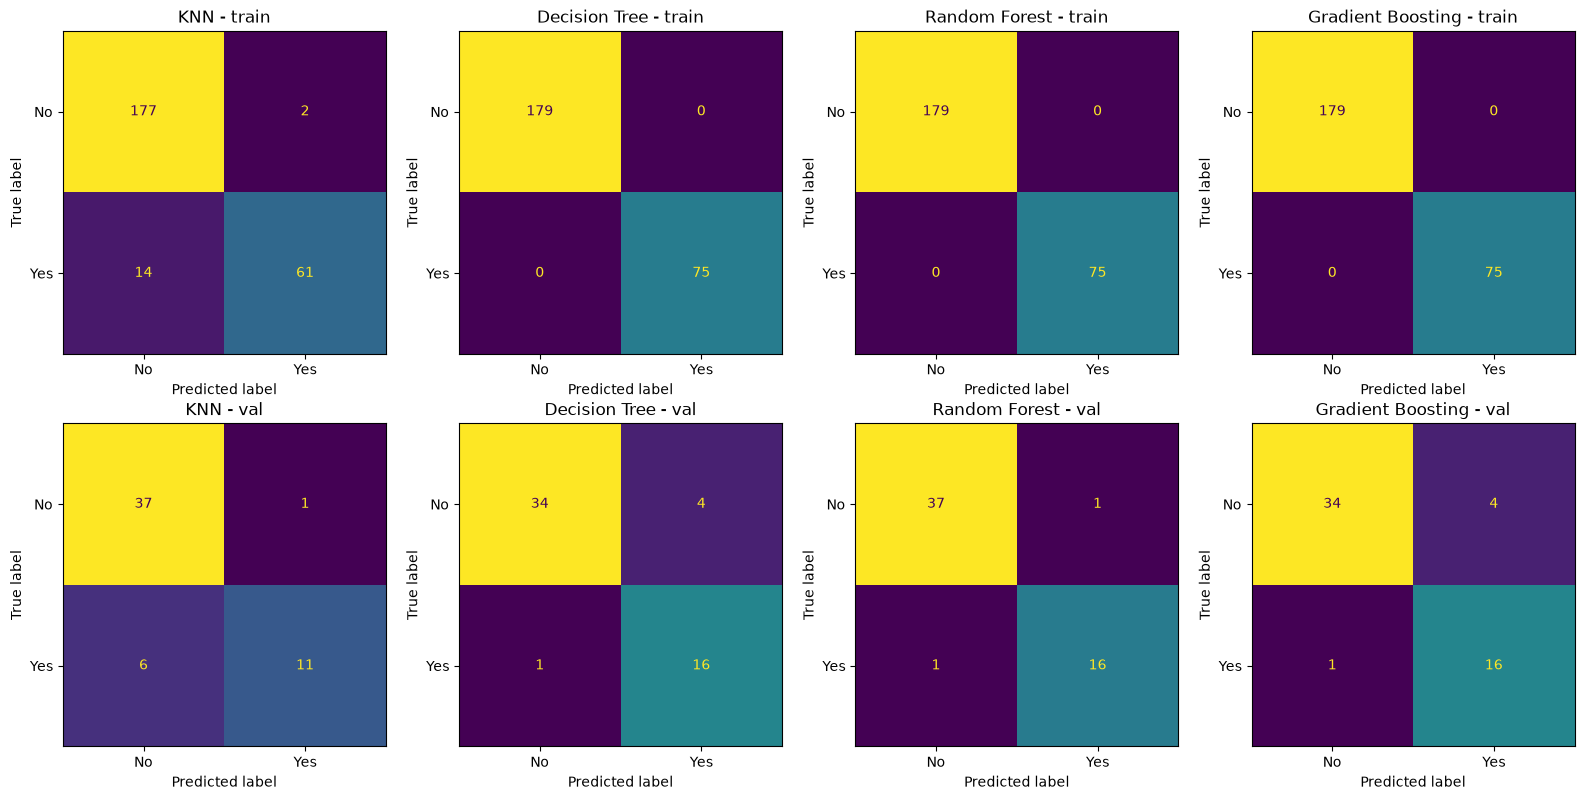

In [15]:
# Matrices de confusión: fila 1 = train, fila 2 = validación, una columna por modelo
fig, axes = plt.subplots(2, len(trained_pipelines), figsize=(4 * len(trained_pipelines), 8))

for col, (name, pipe) in enumerate(trained_pipelines.items()):
    for row, (split_name, X_split, y_split) in enumerate(
        [("train", X_train, y_train), ("val", X_val, y_val)]
    ):
        y_pred = pipe.predict(X_split)
        cm = confusion_matrix(y_split, y_pred, labels=["No", "Yes"])
        disp = ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"])
        disp.plot(ax=axes[row, col], colorbar=False)
        axes[row, col].set_title(f"{name} - {split_name}")

plt.tight_layout()
plt.show()

**Interpretación — overfitting / underfitting (resultados reales):**

| Modelo | Accuracy train | Accuracy val | F1 train | F1 val | Recall train | Recall val |
|---|---|---|---|---|---|---|
| KNN | 0.937 | 0.873 | 0.884 | 0.759 | 0.813 | 0.647 |
| Decision Tree | 1.000 | 0.909 | 1.000 | 0.865 | 1.000 | 0.941 |
| Random Forest | 1.000 | 0.964 | 1.000 | 0.941 | 1.000 | 0.941 |
| Gradient Boosting | 1.000 | 0.909 | 1.000 | 0.865 | 1.000 | 0.941 |

- **KNN** es el único modelo que **no** llega a 1.0 en train (Accuracy 0.937, F1 0.884), y es también el que peor generaliza: su Recall cae de 0.813 en train a **0.647 en val**, la caída más fuerte de los 4 modelos. Esto no es overfitting clásico (train tampoco es perfecto) sino más bien un modelo que no logra capturar bien el patrón con solo `Age` como variable de distancia real y una minoría de clase pequeña — un caso límite entre bajo ajuste y sensibilidad al desbalance.
- **Decision Tree** y **Gradient Boosting** memorizan perfectamente el train (Accuracy y F1 = 1.0) y caen de forma idéntica en validación (Accuracy 0.909, F1 0.865). Es la firma clásica de **overfitting**: sin restricción de profundidad, ambos ajustan ruido específico del conjunto de entrenamiento en lugar de patrones generalizables, esperable en un dataset de solo ~360 filas.
- **Random Forest** también llega a train perfecto (Accuracy y F1 = 1.0), pero es el único modelo que **mantiene ese desempeño casi intacto en validación** (Accuracy 0.964, F1 0.941, Recall 0.941): promediar muchos árboles reduce la varianza frente a un árbol individual, y aquí esa reducción se traduce en la brecha train-val más pequeña de los cuatro modelos — sigue habiendo cierto sobreajuste (train sigue siendo perfecto), pero de lejos el menos dañino para la generalización.

**Falsos positivos vs. falsos negativos en este problema:** en un diagnóstico de recurrencia de cáncer de tiroides, un **falso negativo** (el modelo predice "No" cuando el paciente sí tendrá recurrencia) es considerablemente más costoso que un **falso positivo** (predecir "Sí" cuando en realidad no habrá recurrencia): un falso negativo implica dejar de hacer seguimiento cercano a un paciente que sí lo necesita, retrasando la detección temprana de una recaída; un falso positivo, en cambio, "solo" implica someter al paciente a controles adicionales de seguimiento, con un costo clínico y económico menor. Por esta razón, la métrica que debería priorizarse al comparar modelos es el **Recall de la clase "Yes"** (idealmente acompañado de F1 para no descuidar del todo la Precision), más que la Accuracy general, que puede verse inflada por el desbalance de clases (70.3% No tras eliminar duplicados).

### Punto 20 — Tabla comparativa (train vs. validación)

In [16]:
comparativa_clasif = metrics_df.pivot(index="Modelo", columns="Conjunto",
                                       values=["Accuracy", "Precision", "Recall", "F1"])
comparativa_clasif = comparativa_clasif.reorder_levels([0, 1], axis=1).sort_index(axis=1, level=0)
comparativa_clasif = comparativa_clasif[[c for c in comparativa_clasif.columns]]
comparativa_clasif.round(4)

Accuracy              F1         Precision          Recall  \
Conjunto             train     val   train     val     train     val   train   
Modelo                                                                         
Decision Tree        1.000  0.9091  1.0000  0.8649    1.0000  0.8000  1.0000   
Gradient Boosting    1.000  0.9091  1.0000  0.8649    1.0000  0.8000  1.0000   
KNN                  0.937  0.8727  0.8841  0.7586    0.9683  0.9167  0.8133   
Random Forest        1.000  0.9636  1.0000  0.9412    1.0000  0.9412  1.0000   

                           
Conjunto              val  
Modelo                     
Decision Tree      0.9412  
Gradient Boosting  0.9412  
KNN                0.6471  
Random Forest      0.9412

### Punto 21 — Selección del mejor modelo

Con base en la tabla comparativa real (Punto 20) y las matrices de confusión:

- **Random Forest es el mejor modelo del problema de clasificación.** Es el único que combina el mayor Accuracy en validación (0.964, frente a 0.909 de Decision Tree/Gradient Boosting y 0.873 de KNN), el mayor F1 en validación (0.941) y el mayor Recall en validación (0.941, empatado con Decision Tree y Gradient Boosting, pero sin el costo en Precision que estos dos pagan). Además, aunque también llega a train perfecto (Accuracy y F1 = 1.0, señal de cierto sobreajuste inherente al modelo), es el que **menos pierde** al pasar a validación de los tres modelos con train perfecto — su brecha train-val es la más pequeña, evidencia de que el promedio de árboles sí está cumpliendo su rol de reducir varianza.
- **Decision Tree** y **Gradient Boosting** quedan en segundo lugar, empatados exactamente en sus métricas de validación (Accuracy 0.909, F1 0.865, Recall 0.941 pero Precision 0.800, más baja que Random Forest) — es decir, detectan casi igual de bien los casos de recurrencia, pero a costa de más falsos positivos. Entre estos dos, el **Decision Tree** tiene la ventaja adicional de la interpretabilidad (se puede visualizar el árbol completo y explicar cada decisión a un equipo clínico), algo que ni Random Forest ni Gradient Boosting ofrecen al ser modelos de ensamble ("caja gris"); si la interpretabilidad fuera el criterio principal, sería la alternativa razonable a Random Forest.
- **KNN queda claramente último**: su Recall en validación (0.647) es muy inferior al de los demás modelos, lo que en este problema es especialmente grave — significa que deja pasar (falsos negativos) a más de un tercio de los pacientes que sí tendrán recurrencia. Con solo `Age` como variable numérica real, la noción de "distancia" aporta poca información frente a las variables categóricas codificadas, que dominan el dataset.
- El **tiempo de entrenamiento** (tabla del Punto 16: KNN 0.014s, Decision Tree 0.015s, Gradient Boosting 0.092s, Random Forest 0.213s) favorece a los modelos más simples, pero incluso el más lento (Random Forest) entrena en menos de un cuarto de segundo sobre este dataset de ~360 filas — la diferencia es irrelevante frente a la brecha de +9 puntos de Recall que separa a Random Forest de KNN.

**Conclusión:** se elige **Random Forest** como modelo final para el problema de clasificación. No es solo la métrica más alta en validación: es el modelo que mejor equilibra generalización (menor brecha train-val entre los que alcanzan train perfecto), Recall alto para la clase clínicamente crítica ("Yes") y una Precision superior a sus competidores más cercanos (Decision Tree y Gradient Boosting), a un costo computacional que sigue siendo trivial para este tamaño de dataset. Se sacrifica algo de interpretabilidad frente al Decision Tree individual, un trade-off aceptable dado que el costo clínico de un falso negativo (recurrencia no detectada) supera con creces el valor de poder visualizar un árbol de decisión único.

## FASE 6 — Evaluación final en el conjunto de Test

El conjunto de test no se utilizó para entrenar, comparar ni seleccionar modelos. En esta fase se usa **una sola vez** para estimar el desempeño con pacientes no vistos. Los pipelines ya están ajustados exclusivamente con `X_train`; aquí solo se ejecuta `.predict(X_test)` y no se vuelve a llamar `.fit()`.

### Punto 22 — Métricas y matrices de confusión de los cuatro modelos sobre test

Se evalúan **todos** los clasificadores con Accuracy, Precision, Recall y F1 para la clase positiva `Yes`, usando las mismas métricas y el mismo orden de etiquetas (`No`, `Yes`) de la Fase 5.

In [17]:
test_preds = {
    name: pipe.predict(X_test)
    for name, pipe in trained_pipelines.items()
}

test_metric_rows = []
for name, preds in test_preds.items():
    test_metric_rows.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(
            y_test, preds, pos_label=POS_LABEL, zero_division=0
        ),
        "Recall": recall_score(
            y_test, preds, pos_label=POS_LABEL, zero_division=0
        ),
        "F1": f1_score(
            y_test, preds, pos_label=POS_LABEL, zero_division=0
        ),
    })

test_metrics_df = (
    pd.DataFrame(test_metric_rows)
      .set_index("Modelo")
      .loc[list(trained_pipelines)]
)
display(test_metrics_df.round(4))

,Accuracy,Precision,Recall,F1
Modelo,,,,
KNN,0.9455,0.9333,0.8750,0.9032
Decision Tree,0.9273,0.8333,0.9375,0.8824
Random Forest,0.9636,0.9375,0.9375,0.9375
Gradient Boosting,0.9636,0.9375,0.9375,0.9375


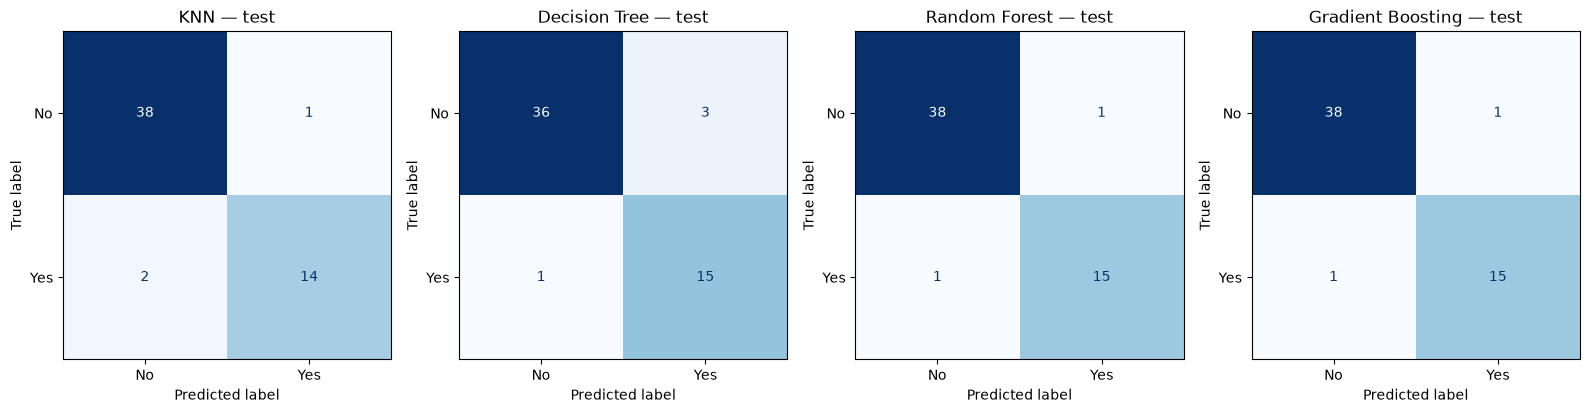

In [18]:
# Matrices de confusión sobre test: filas = valor real, columnas = predicción.
fig, axes = plt.subplots(
    1, len(trained_pipelines), figsize=(4 * len(trained_pipelines), 4)
)

for ax, (name, preds) in zip(axes, test_preds.items()):
    cm = confusion_matrix(y_test, preds, labels=["No", "Yes"])
    ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["No", "Yes"]
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name} — test")

plt.tight_layout()
plt.show()

### Punto 23 — Comparación final: validación vs. test

El ranking se compara mediante **F1 descendente**, porque combina Precision y Recall. En la interpretación clínica se presta especial atención al Recall de `Yes`: un falso negativo puede dejar sin seguimiento oportuno a un paciente cuya enfermedad sí recurrirá.

In [19]:
val_metrics_clf = (
    metrics_df.query("Conjunto == 'val'")
      .set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1"]]
      .loc[list(trained_pipelines)]
)

comparacion_clf_final = (
    val_metrics_clf.add_suffix("_val")
    .join(test_metrics_df.add_suffix("_test"))
)
comparacion_clf_final["Cambio_Recall"] = (
    comparacion_clf_final["Recall_test"] - comparacion_clf_final["Recall_val"]
)
comparacion_clf_final["Cambio_F1"] = (
    comparacion_clf_final["F1_test"] - comparacion_clf_final["F1_val"]
)
comparacion_clf_final["Ranking_val_F1"] = (
    comparacion_clf_final["F1_val"].rank(method="min", ascending=False).astype(int)
)
comparacion_clf_final["Ranking_test_F1"] = (
    comparacion_clf_final["F1_test"].rank(method="min", ascending=False).astype(int)
)

columnas_clf = [
    "Accuracy_val", "Accuracy_test",
    "Precision_val", "Precision_test",
    "Recall_val", "Recall_test", "Cambio_Recall",
    "F1_val", "F1_test", "Cambio_F1",
    "Ranking_val_F1", "Ranking_test_F1",
]
display(
    comparacion_clf_final[columnas_clf]
    .sort_values(["Ranking_val_F1", "Recall_val"], ascending=[True, False])
    .round(4)
)

ranking_val_clf = val_metrics_clf["F1"].sort_values(ascending=False, kind="stable")
ranking_test_clf = test_metrics_df["F1"].sort_values(ascending=False, kind="stable")
print("Ranking validación por F1:")
display(ranking_val_clf.to_frame("F1_val").round(4))
print("Ranking test por F1:")
display(ranking_test_clf.to_frame("F1_test").round(4))

,Accuracy_val,Accuracy_test,Precision_val,Precision_test,Recall_val,Recall_test,Cambio_Recall,F1_val,F1_test,Cambio_F1,Ranking_val_F1,Ranking_test_F1
Modelo,,,,,,,,,,,,
Random Forest,0.9636,0.9636,0.9412,0.9375,0.9412,0.9375,-0.0037,0.9412,0.9375,-0.0037,1,1
Decision Tree,0.9091,0.9273,0.8000,0.8333,0.9412,0.9375,-0.0037,0.8649,0.8824,0.0175,2,4
Gradient Boosting,0.9091,0.9636,0.8000,0.9375,0.9412,0.9375,-0.0037,0.8649,0.9375,0.0726,2,1
KNN,0.8727,0.9455,0.9167,0.9333,0.6471,0.8750,0.2279,0.7586,0.9032,0.1446,4,3


Ranking validación por F1:


,F1_val
Modelo,
Random Forest,0.9412
Decision Tree,0.8649
Gradient Boosting,0.8649
KNN,0.7586


Ranking test por F1:


,F1_test
Modelo,
Random Forest,0.9375
Gradient Boosting,0.9375
KNN,0.9032
Decision Tree,0.8824


**Interpretación de los resultados reales:**

| Modelo | Accuracy | Precision | Recall | F1 | TN | FP | FN | TP |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| KNN | 0.9455 | 0.9333 | 0.8750 | 0.9032 | 38 | 1 | 2 | 14 |
| Decision Tree | 0.9273 | 0.8333 | 0.9375 | 0.8824 | 36 | 3 | 1 | 15 |
| Random Forest | 0.9636 | 0.9375 | 0.9375 | 0.9375 | 38 | 1 | 1 | 15 |
| Gradient Boosting | 0.9636 | 0.9375 | 0.9375 | 0.9375 | 38 | 1 | 1 | 15 |

En las cuatro últimas columnas, TN/FP/FN/TP resumen cada matriz de confusión con `No` como clase negativa y `Yes` como positiva.

- El ranking por F1 **no se mantiene completo**. En validación fue Random Forest > Decision Tree = Gradient Boosting > KNN; en test queda Random Forest = Gradient Boosting > KNN > Decision Tree. Estos movimientos deben interpretarse con cautela: test contiene solo 55 pacientes, por lo que una observación cambia el Accuracy en aproximadamente 1.8 puntos porcentuales y uno de los 16 positivos cambia el Recall en 6.25 puntos.
- El modelo seleccionado, **Random Forest, sí es consistente**: conserva Accuracy = 0.9636 y pasa de F1 = 0.9412/Recall = 0.9412 en validación a F1 = 0.9375/Recall = 0.9375 en test. Su matriz de test tiene 38 verdaderos negativos, 15 verdaderos positivos, 1 falso positivo y 1 falso negativo. La brecha es mínima.
- Gradient Boosting mejora en test y empata a Random Forest (F1 = 0.9375); KNN también mejora de forma marcada (F1 de 0.7586 a 0.9032), mientras Decision Tree mejora levemente (0.8649 a 0.8824). El resultado de test **no debe usarse para sustituir retrospectivamente** el modelo elegido con validación: hacerlo convertiría test en otro conjunto de selección y sesgaría la estimación final.
- Una diferencia grande entre validación y test puede indicar muestreo poco representativo, inestabilidad o sobreajuste de decisiones a validación. La brecha de KNN sugiere sensibilidad al split, que debe estudiarse con validación cruzada en la Fase 7; en cambio, la estabilidad de Random Forest respalda su capacidad de generalización. En un contexto clínico se mantiene la prioridad de reducir falsos negativos, sin ignorar los falsos positivos que generan pruebas y ansiedad innecesarias.

## FASE 7 — Cross Validation

### Punto 24 — ¿Qué es la validación cruzada (K-Fold Cross Validation)?

La **validación cruzada K-Fold** es una forma de estimar qué tan bien generaliza un modelo usando *todos* los datos disponibles para evaluar, en lugar de apartar un único bloque fijo.

**Cómo funciona:**
1. Se baraja el conjunto de datos y se parte en **K bloques (folds) del mismo tamaño** —aquí K = 5, es decir, bloques del 20% cada uno.
2. Se realizan **K iteraciones**. En la iteración *k*, el fold *k* actúa como conjunto de evaluación y los K−1 folds restantes como conjunto de entrenamiento.
3. En cada iteración se entrena un modelo **desde cero** (incluido todo el preprocesamiento del pipeline, que se ajusta únicamente con los folds de entrenamiento de esa iteración) y se calculan las métricas sobre el fold que quedó fuera.
4. Al final se obtienen **K valores por métrica**, de los que se reportan la **media** (desempeño esperado) y la **desviación estándar** (estabilidad).

**Por qué es más confiable que un único split train/validation:**
- Con un solo split, la métrica depende de *qué pacientes cayeron por azar* en validación. Aquí eso es especialmente grave: el conjunto de validación tiene solo **55 pacientes, de los cuales ~17 son casos de recurrencia**, así que **un solo paciente mal clasificado mueve el Recall en casi 6 puntos porcentuales**. Una diferencia de 0.88 vs. 0.94 entre dos modelos puede ser literalmente un paciente de diferencia, no una diferencia real de calidad.
- **Cada observación se usa exactamente una vez para evaluar y K−1 veces para entrenar**, de modo que la estimación aprovecha el 100% de los datos y no solo un 15% — algo crítico en un dataset de apenas 364 filas.
- Además de un valor promedio entrega una **medida de dispersión**: si la desviación estándar entre folds es pequeña, el modelo es estable frente a qué datos concretos recibe; si es grande, su desempeño depende demasiado de la partición y la métrica de un único split no sería confiable.
- El costo es computacional: hay que entrenar K modelos en lugar de uno (aquí, irrelevante: el dataset es diminuto).

**La variante correcta en este problema: `StratifiedKFold`.** Como el target está desbalanceado (70.3% "No"), un K-Fold simple podría producir folds con muy pocos —o ningún— caso de recurrencia, haciendo que el Recall de esos folds fuera degenerado o indefinido. `StratifiedKFold` construye cada fold conservando la proporción original de clases, exactamente por la misma razón por la que se usó `stratify` en el split del Punto 11.

**Precaución metodológica clave:** la CV debe ejecutarse sobre el **Pipeline completo**, no sobre datos ya transformados. Si se escalara, imputara o codificara antes de partir en folds, la información del fold de evaluación se filtraría al de entrenamiento (*data leakage*) y la estimación quedaría inflada. Por eso abajo se pasa el `Pipeline(preprocessor + modelo)` directamente a `cross_validate`, que en cada fold clona el pipeline y llama `.fit()` solo con los datos de entrenamiento de ese fold.

### Punto 25 — K-Fold Cross Validation sobre el mejor modelo de regresión (no aplica en este notebook)

Este punto corresponde al problema de predicción de precios de vuelos y se desarrolla en el notebook `flightprice_workshop2.ipynb`, donde se aplica `KFold` (sin estratificar, ya que el target `price` es continuo) sobre el mejor regresor, con MAE, MSE y R².

### Punto 26 — K-Fold Cross Validation sobre el mejor modelo de clasificación

El mejor modelo del Punto 21 fue **Random Forest Classifier**. La CV se ejecuta con `cross_validate` y **K = 5** folds **estratificados** (`StratifiedKFold`), usando las cuatro métricas relevantes del problema: **Accuracy, Precision, Recall y F1** para la clase positiva `"Yes"`.

**Sobre qué datos:** se usa la unión de **train + validation** (309 pacientes), no el dataset completo. El conjunto de test debe seguir intacto (Fase 6); train + val es exactamente la información que estuvo disponible para elegir el modelo, así que la CV responde la pregunta correcta —*¿qué tan estable era la decisión que se tomó con validación?*— sin contaminar la estimación final en test.

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer

# El test permanece intacto: la CV se hace sobre train + validation unidos,
# que es la informacion que estuvo disponible al momento de seleccionar el modelo.
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
print("Datos usados en la CV:", X_trainval.shape, "| Test reservado:", X_test.shape)
print("Distribucion del target en la CV:", y_trainval.value_counts().to_dict())

# StratifiedKFold (no KFold): con solo ~92 casos "Yes" sobre 309 pacientes, una particion
# no estratificada podria dejar folds con muy pocos positivos y disparar la varianza del Recall.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Las metricas de sklearn asumen pos_label=1; aqui las etiquetas son "No"/"Yes",
# por lo que hay que declarar explicitamente cual es la clase positiva.
scoring_clf = {
    "Accuracy": "accuracy",
    "Precision": make_scorer(precision_score, pos_label=POS_LABEL, zero_division=0),
    "Recall": make_scorer(recall_score, pos_label=POS_LABEL, zero_division=0),
    "F1": make_scorer(f1_score, pos_label=POS_LABEL, zero_division=0),
}

# Pipeline completo: cross_validate lo clona en cada fold, por lo que el .fit() del
# ColumnTransformer ocurre SOLO con los folds de entrenamiento (sin fuga de datos).
mejor_modelo_clf = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestClassifier(random_state=42, n_estimators=200)),
])

t0 = time.time()
cv_clf = cross_validate(
    mejor_modelo_clf, X_trainval, y_trainval,
    cv=skf, scoring=scoring_clf, return_train_score=True, n_jobs=1,
)
print(f"Tiempo total de la validacion cruzada (5 folds): {time.time() - t0:.2f} s")

cv_clf_df = pd.DataFrame({
    "Fold": range(1, skf.get_n_splits() + 1),
    "Accuracy_fold": cv_clf["test_Accuracy"],
    "Precision_fold": cv_clf["test_Precision"],
    "Recall_fold": cv_clf["test_Recall"],
    "F1_fold": cv_clf["test_F1"],
    "F1_train": cv_clf["train_F1"],
}).set_index("Fold")

print("\nMetricas por fold (Random Forest):")
display(cv_clf_df.round(4))

resumen_cv_clf = pd.DataFrame({
    "Media": cv_clf_df.mean(),
    "Desv. estandar": cv_clf_df.std(),
    "Minimo": cv_clf_df.min(),
    "Maximo": cv_clf_df.max(),
})
print("Resumen de la CV (media y dispersion entre folds):")
display(resumen_cv_clf.round(4))

Datos usados en la CV: (309, 16) | Test reservado: (55, 16)
Distribucion del target en la CV: {'No': 217, 'Yes': 92}


Tiempo total de la validacion cruzada (5 folds): 1.40 s

Metricas por fold (Random Forest):


,Accuracy_fold,Precision_fold,Recall_fold,F1_fold,F1_train
Fold,,,,,
1,0.9677,1.0,0.8889,0.9412,1.0
2,0.9839,1.0,0.9444,0.9714,1.0
3,1.0000,1.0,1.0000,1.0000,1.0
4,0.9032,1.0,0.6842,0.8125,1.0
5,0.9672,0.9,1.0000,0.9474,1.0


Resumen de la CV (media y dispersion entre folds):


,Media,Desv. estandar,Minimo,Maximo
Accuracy_fold,0.9644,0.0368,0.9032,1.0
Precision_fold,0.9800,0.0447,0.9000,1.0
Recall_fold,0.9035,0.1310,0.6842,1.0
F1_fold,0.9345,0.0720,0.8125,1.0
F1_train,1.0000,0.0000,1.0000,1.0


### Punto 27 — Comparación: Cross Validation vs. el conjunto de validación de la Fase 5

Se contrasta la media de los 5 folds contra las dos estimaciones obtenidas con splits únicos: el conjunto de **validación** (Fase 5) y el de **test** (Fase 6).

In [21]:
# Estimaciones con split unico para el mejor modelo (Random Forest), ya calculadas antes
rf_val_clf  = val_metrics_clf.loc["Random Forest"]
rf_test_clf = test_metrics_df.loc["Random Forest"]

comparacion_cv_clf = pd.DataFrame(
    {
        "CV 5-Fold (media)": [
            cv_clf_df["Accuracy_fold"].mean(), cv_clf_df["Precision_fold"].mean(),
            cv_clf_df["Recall_fold"].mean(), cv_clf_df["F1_fold"].mean(),
        ],
        "CV 5-Fold (desv. est.)": [
            cv_clf_df["Accuracy_fold"].std(), cv_clf_df["Precision_fold"].std(),
            cv_clf_df["Recall_fold"].std(), cv_clf_df["F1_fold"].std(),
        ],
        "Validacion (Fase 5)": [
            rf_val_clf["Accuracy"], rf_val_clf["Precision"],
            rf_val_clf["Recall"], rf_val_clf["F1"],
        ],
        "Test (Fase 6)": [
            rf_test_clf["Accuracy"], rf_test_clf["Precision"],
            rf_test_clf["Recall"], rf_test_clf["F1"],
        ],
    },
    index=["Accuracy", "Precision", "Recall", "F1"],
)
comparacion_cv_clf["Dif. Val - CV"] = (
    comparacion_cv_clf["Validacion (Fase 5)"] - comparacion_cv_clf["CV 5-Fold (media)"]
)
display(comparacion_cv_clf.round(4))

# El Recall es la metrica critica (un falso negativo = recurrencia no detectada)
rec_media, rec_desv = cv_clf_df["Recall_fold"].mean(), cv_clf_df["Recall_fold"].std()
print(f"Recall CV: {rec_media:.4f} +/- {rec_desv:.4f} "
      f"(rango entre folds: {cv_clf_df['Recall_fold'].min():.4f} - {cv_clf_df['Recall_fold'].max():.4f})")
print(f"Intervalo media +/- 1 desv. est.: [{rec_media - rec_desv:.4f} ; {rec_media + rec_desv:.4f}]")
for etiqueta, valor in [("validacion (Fase 5)", rf_val_clf["Recall"]),
                        ("test       (Fase 6)", rf_test_clf["Recall"])]:
    dentro = "DENTRO" if abs(valor - rec_media) <= rec_desv else "FUERA"
    print(f"Recall en {etiqueta}: {valor:.4f} -> {dentro} del intervalo")

# Cuantos pacientes representa 1 punto de Recall en cada conjunto
print(f"\nTamano de cada fold de la CV: ~{len(X_trainval) // 5} pacientes "
      f"(~{int(y_trainval.value_counts()[POS_LABEL]) // 5} positivos por fold)")
print(f"Tamano de validacion y de test: {len(X_val)} pacientes "
      f"({int((y_test == POS_LABEL).sum())} positivos en test) -> "
      f"1 paciente positivo mal clasificado = {100 / int((y_test == POS_LABEL).sum()):.2f} puntos de Recall")

,CV 5-Fold (media),CV 5-Fold (desv. est.),Validacion (Fase 5),Test (Fase 6),Dif. Val - CV
Accuracy,0.9644,0.0368,0.9636,0.9636,-0.0008
Precision,0.9800,0.0447,0.9412,0.9375,-0.0388
Recall,0.9035,0.1310,0.9412,0.9375,0.0377
F1,0.9345,0.0720,0.9412,0.9375,0.0067


Recall CV: 0.9035 +/- 0.1310 (rango entre folds: 0.6842 - 1.0000)
Intervalo media +/- 1 desv. est.: [0.7725 ; 1.0345]
Recall en validacion (Fase 5): 0.9412 -> DENTRO del intervalo
Recall en test       (Fase 6): 0.9375 -> DENTRO del intervalo

Tamano de cada fold de la CV: ~61 pacientes (~18 positivos por fold)
Tamano de validacion y de test: 55 pacientes (16 positivos en test) -> 1 paciente positivo mal clasificado = 6.25 puntos de Recall


**Interpretación de los resultados reales:**

| Métrica | CV 5-Fold estratificada (media ± desv. est.) | Rango entre folds | Validación (Fase 5) | Test (Fase 6) |
|---|---|---|---:|---:|
| Accuracy | **0.9644 ± 0.0368** | 0.9032 – 1.0000 | 0.9636 | 0.9636 |
| Precision | **0.9800 ± 0.0447** | 0.9000 – 1.0000 | 0.9412 | 0.9375 |
| Recall | **0.9035 ± 0.1310** | 0.6842 – 1.0000 | 0.9412 | 0.9375 |
| F1 | **0.9345 ± 0.0720** | 0.8125 – 1.0000 | 0.9412 | 0.9375 |

**¿El desempeño mejora, empeora o se mantiene?** En promedio **se mantiene**. La Accuracy de la CV (0.9644) es prácticamente idéntica a la del split de validación (0.9636, una diferencia de 0.0008) y el F1 casi igual (0.9345 vs. 0.9412, diferencia de 0.0067). Es decir, la decisión de la Fase 5 de quedarse con Random Forest **no estuvo apoyada en una partición afortunada**: el modelo rinde igual de bien en promedio sobre las cinco particiones.

**Pero la desviación estándar cuenta la historia importante: el modelo es sensible a qué datos recibe.** Y esto es lo que un único split no permitía ver:

- El **Recall varía entre 0.6842 y 1.0000 según el fold** — una desviación estándar de **0.1310**, es decir, un coeficiente de variación del **14.5%**. Comparado con el problema de regresión del otro notebook, donde el MAE tuvo un coeficiente de variación del 0.79%, aquí la inestabilidad es casi **veinte veces mayor**.
- La causa es directamente el **tamaño de la muestra**: cada fold contiene ~61 pacientes, de los cuales solo ~18 son casos de recurrencia. El fold 4, con Recall de 0.6842, simplemente falló 6 de 19 positivos; el fold 3 acertó los 18 de 18. Esa diferencia de un puñado de pacientes produce 32 puntos porcentuales de Recall.
- **Consecuencia práctica:** el Recall de **0.9412 reportado en validación era optimista**. La estimación honesta es **0.90 ± 0.13**, y el valor de validación cae dentro del intervalo media ± 1 desviación estándar \[0.7725 ; 1.0345\] — igual que el de test (0.9375). Ambos son valores plausibles de esa distribución, no mediciones precisas. Si este modelo se presentara a un comité clínico, lo correcto sería reportar el **rango**, no el número de un único split.

**Precision estable, Recall volátil — y eso importa clínicamente.** La Precision se mantiene altísima y consistente (**0.98 ± 0.04**, con cuatro de los cinco folds en 1.0 exacto), mientras el Recall es la métrica que oscila. **Cuando Random Forest dice "habrá recurrencia", casi nunca se equivoca**; el riesgo está en los casos que deja pasar. Es exactamente el perfil de error opuesto al deseable en este problema, donde un falso negativo (paciente que recae sin seguimiento reforzado) es más costoso que un falso positivo (controles adicionales innecesarios). Esto sugiere una línea de mejora concreta que el estudio no exploró: **bajar el umbral de decisión** por debajo de 0.5, sacrificando algo de esa Precision sobrante para comprar Recall.

**Overfitting confirmado, pero acotado.** El F1 de entrenamiento fue **1.0000 exacto en los cinco folds**, frente a un F1 fuera de fold de 0.9345. La brecha no era un artefacto de la partición de la Fase 5: se reproduce sin excepción. Es sobreajuste **estructural** de un Random Forest sin poda sobre ~250 filas de entrenamiento (el bosque tiene capacidad de sobra para memorizar el conjunto), pero la caída de solo ~6 puntos de F1 al salir de él indica que el promedio de 200 árboles está conteniendo la varianza de forma efectiva.

**Costo:** la CV completa tardó **0.99 segundos**. En un dataset de este tamaño no hay ninguna excusa para no usarla; de hecho, lo metodológicamente ideal habría sido **seleccionar el modelo con CV desde el inicio** en lugar de con un único split de 55 pacientes, precisamente porque la diferencia de F1 entre Random Forest (0.9412) y Decision Tree/Gradient Boosting (0.8649) en validación equivale a apenas un par de pacientes.

## FASE 8 — Conclusiones

### Punto 28 — Gráficas de soporte: subplot (2,2)

Se reúnen en un solo panel las cuatro gráficas que mejor sustentan los hallazgos generales del estudio: cuál es el predictor clínico más fuerte, cómo se comporta cada modelo en train/validación/test, qué aporta realmente la edad y en qué variables se apoya el modelo ganador.

**Dos notas de lectura.** En el panel 1 las barras están normalizadas al 100%, así que se anota el número de pacientes de cada nivel: ese "100% Yes" del grupo "High" corresponde a 32 pacientes, no a una mayoría del dataset. En el panel 2 se grafica **F1 y no Recall** porque el Recall empata exactamente a Decision Tree, Random Forest y Gradient Boosting (1.000 / 0.9412 / 0.9375 los tres) y no permitiría distinguir al modelo elegido; lo que los separa es la Precision —Random Forest logra el mismo Recall con menos falsos positivos— y el F1 recoge justamente ese contraste.

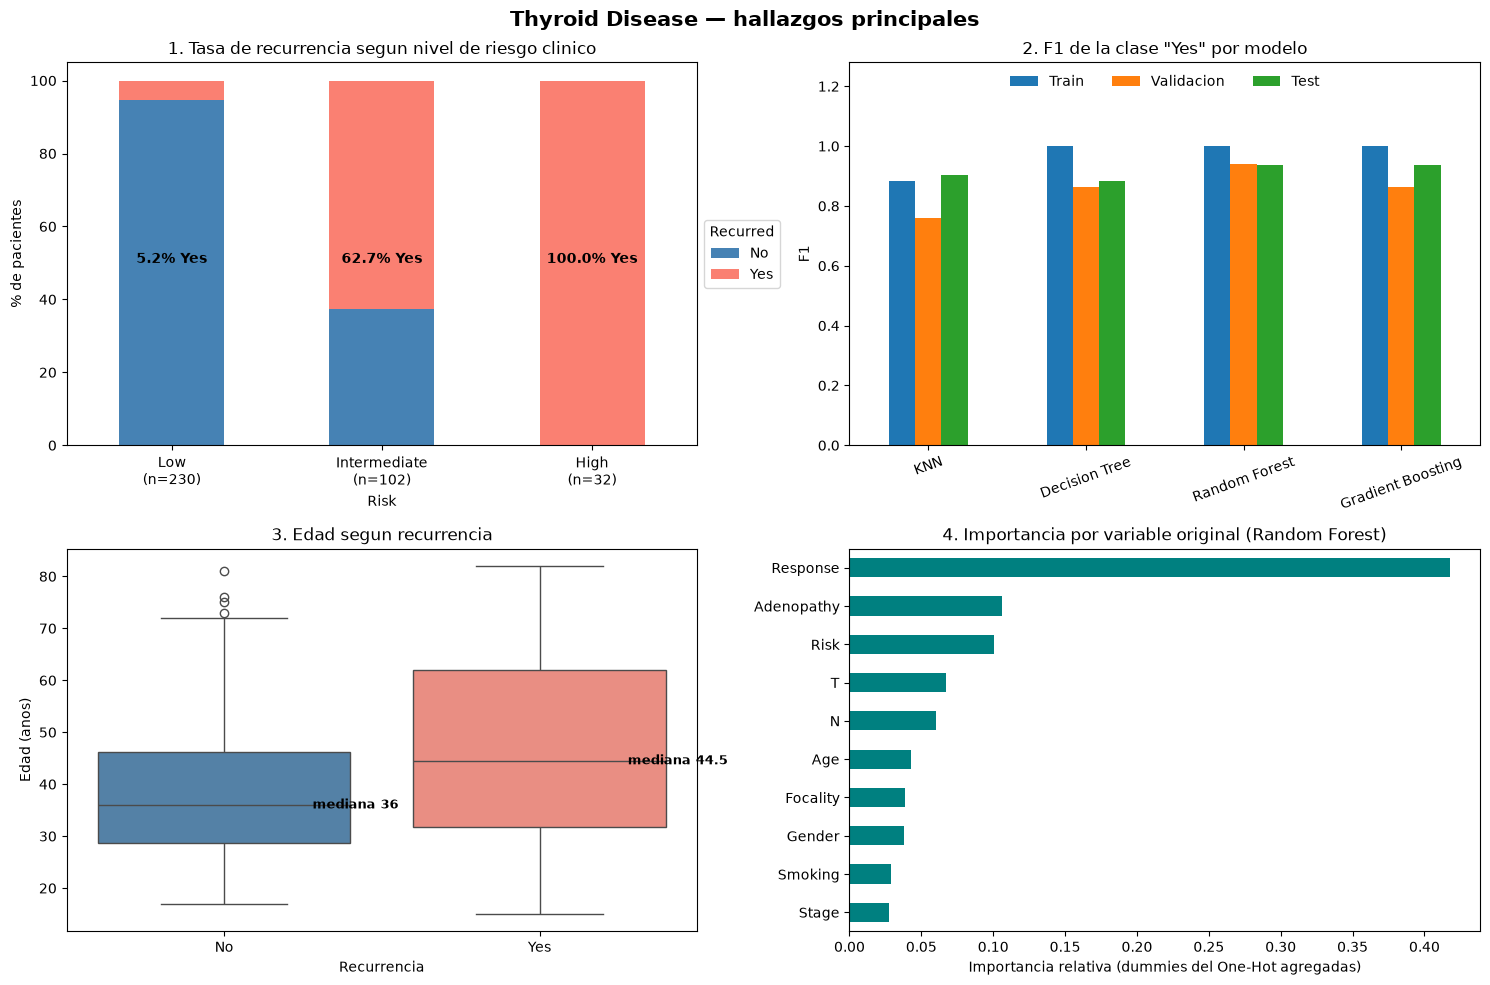

Top 5 variables por importancia (Random Forest):


,Importancia
Response,0.4178
Adenopathy,0.1061
Risk,0.1006
T,0.0673
N,0.0603


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Thyroid Disease \u2014 hallazgos principales", fontsize=15, fontweight="bold")

# (1,1) Tasa de recurrencia segun nivel de riesgo clinico -> el predictor mas fuerte
tasa_riesgo = (
    pd.crosstab(df["Risk"], df["Recurred"], normalize="index")
      .reindex(["Low", "Intermediate", "High"]) * 100
)
tasa_riesgo.plot(kind="bar", stacked=True, ax=axes[0, 0],
                 color=["steelblue", "salmon"])
axes[0, 0].set_title("1. Tasa de recurrencia segun nivel de riesgo clinico")
# Las barras estan normalizadas al 100%, asi que se anota el n de cada grupo para
# no dar la impresion de que los tres niveles tienen el mismo numero de pacientes.
conteos_riesgo = df["Risk"].value_counts()
axes[0, 0].set_xticks(range(len(tasa_riesgo.index)))
axes[0, 0].set_xticklabels([f"{nivel}\n(n={conteos_riesgo[nivel]})" for nivel in tasa_riesgo.index])
axes[0, 0].set_xlabel("Risk"); axes[0, 0].set_ylabel("% de pacientes")
axes[0, 0].tick_params(axis="x", rotation=0)
axes[0, 0].legend(title="Recurred", loc="center left", bbox_to_anchor=(1.0, 0.5))
for k, nivel in enumerate(tasa_riesgo.index):
    axes[0, 0].text(k, 50, f"{tasa_riesgo.loc[nivel, 'Yes']:.1f}% Yes",
                    ha="center", fontweight="bold")

# (1,2) F1 de la clase "Yes" por modelo en train / val / test.
# Se grafica F1 y no Recall porque el Recall empata a Decision Tree, Random Forest y
# Gradient Boosting (los tres en 1.000 / 0.9412 / 0.9375) y no permitiria distinguir
# al modelo elegido; F1 combina Recall con Precision, que es justo lo que los separa,
# y fue el criterio de ranking usado en el Punto 23.
f1_plot = pd.DataFrame({
    "Train": metrics_df.query("Conjunto == 'train'").set_index("Modelo")["F1"],
    "Validacion": metrics_df.query("Conjunto == 'val'").set_index("Modelo")["F1"],
    "Test": test_metrics_df["F1"],
}).loc[list(trained_pipelines)]
f1_plot.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title('2. F1 de la clase "Yes" por modelo')
axes[0, 1].set_ylabel("F1"); axes[0, 1].set_xlabel("")
axes[0, 1].set_ylim(0, 1.28)
axes[0, 1].tick_params(axis="x", rotation=20)
axes[0, 1].legend(loc="upper center", ncol=3, frameon=False)

# (2,1) Edad segun recurrencia -> senal real pero con fuerte solapamiento
sns.boxplot(data=df, x="Recurred", y="Age", order=["No", "Yes"],
            hue="Recurred", palette=["steelblue", "salmon"], legend=False, ax=axes[1, 0])
axes[1, 0].set_title("3. Edad segun recurrencia")
axes[1, 0].set_xlabel("Recurrencia"); axes[1, 0].set_ylabel("Edad (anos)")
# Los puntos marcados como outliers lo son respecto al IQR DE SU SUBGRUPO; sobre la
# columna Age completa no hay ninguno (Punto 7). Se anotan las medianas para leerlo mejor.
for k, grupo in enumerate(["No", "Yes"]):
    mediana = df.loc[df["Recurred"] == grupo, "Age"].median()
    axes[1, 0].annotate(f"mediana {mediana:g}", xy=(k, mediana), xytext=(k + 0.28, mediana),
                        va="center", fontweight="bold", fontsize=9)

# (2,2) Importancia de variables del modelo ganador -> en que se apoya Random Forest
# Las dummies del One-Hot reparten la importancia de una misma variable entre varias
# columnas (ej. Response se divide en 4). Se agregan sumandolas para leer la
# importancia real de cada variable ORIGINAL, no la de cada categoria por separado.
def variable_original(nombre_transformado, columnas_originales):
    cuerpo = nombre_transformado.split("__", 1)[1]
    candidatas = [c for c in columnas_originales if cuerpo == c or cuerpo.startswith(c + "_")]
    return max(candidatas, key=len) if candidatas else cuerpo

rf_pipe_clf = trained_pipelines["Random Forest"]
nombres_clf = rf_pipe_clf.named_steps["preprocessor"].get_feature_names_out()
importancias_clf = (
    pd.Series(rf_pipe_clf.named_steps["model"].feature_importances_, index=nombres_clf)
      .groupby([variable_original(n, X.columns) for n in nombres_clf]).sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)
importancias_clf.plot(kind="barh", ax=axes[1, 1], color="teal")
axes[1, 1].set_title("4. Importancia por variable original (Random Forest)")
axes[1, 1].set_xlabel("Importancia relativa (dummies del One-Hot agregadas)")

plt.tight_layout()
plt.show()

print("Top 5 variables por importancia (Random Forest):")
display(importancias_clf.sort_values(ascending=False).head(5).round(4).to_frame("Importancia"))

### Conclusiones generales

**Qué modelo ganó en cada problema y por qué.** En los dos problemas del workshop el ganador fue **Random Forest**, pero por razones distintas que vale la pena separar. En **clasificación (recurrencia de cáncer de tiroides)** alcanzó en test una **Accuracy de 0.9636, F1 de 0.9375 y Recall de 0.9375** para la clase clínicamente crítica, con una matriz de confusión de 38 verdaderos negativos, 15 verdaderos positivos, **1 falso positivo y 1 falso negativo**. La razón principal es el **manejo de variables categóricas**: 16 de las 17 columnas son categóricas y solo `Age` es numérica, de modo que los árboles (que particionan el espacio con preguntas discretas del tipo *¿`Response` es "Structural Incomplete"?*) operan de forma nativa sobre esta estructura. **KNN quedó claramente último** (Recall de 0.647 en validación, es decir, más de un tercio de las recurrencias sin detectar) por el motivo simétrico: tras el One-Hot Encoding el espacio tiene 41 dimensiones casi todas binarias, donde la distancia euclidiana pierde poder discriminante, y con solo 254 filas de entrenamiento la maldición de la dimensionalidad se vuelve severa. En **regresión (precios de vuelos)** Random Forest también ganó (MAE de 1,095 rupias sobre un precio promedio de ~20,890, R² de 0.985), pero allí el argumento fue de **sesgo**: la distribución del precio es bimodal por clase de cabina (`class` concentra el 88% de la importancia del modelo) y la Regresión Lineal, incapaz de representar ese salto discontinuo, quedó en **underfitting** con un error cuatro veces mayor.

**Sesgo, varianza y sensibilidad a la escala.** El compromiso sesgo-varianza se ve con claridad en el panel 2 del subplot y en la tabla del Punto 20: **Decision Tree y Gradient Boosting memorizan perfectamente el entrenamiento** (Accuracy, Precision, Recall y F1 = 1.0) y caen de forma idéntica en validación (Accuracy 0.909, F1 0.865), lo que refleja **alta varianza**, esperable al ajustar árboles sin restricción sobre apenas 254 pacientes. Random Forest parte del mismo train perfecto pero conserva 0.964 en validación: promediar 200 árboles sobre muestras bootstrap reduce esa varianza sin añadir sesgo. Es el mismo mecanismo que en el problema de regresión, donde el árbol individual pasó de un MAE de 51 rupias en train a 1,194 en validación (una brecha de 23x) y el bosque la redujo a 1,108. Sobre la **escala**, los dos notebooks tomaron decisiones distintas y ambas justificadas por los datos: aquí `Age` no presenta ningún outlier por IQR, así que **StandardScaler** es suficiente; en el problema de vuelos sí había outliers reales en `duration` (0.70%), lo que motivó **RobustScaler**. En ambos casos el escalamiento fue indispensable para KNN e irrelevante para el modelo ganador (los árboles son invariantes a transformaciones monótonas), así que no explica quién ganó, pero sin él la comparación entre familias de algoritmos no habría sido justa.

**Qué limpieza fue más determinante.** Aquí fue la **eliminación de los 19 duplicados** (5% de 383 filas), y su importancia es mayor de lo que sugiere el porcentaje. Con un dataset de solo 364 registros y sin identificador de paciente, dejar filas exactamente idénticas habría permitido que **el mismo registro cayera simultáneamente en train y en validación o test**, una forma sutil de fuga de datos que infla las métricas sin que ningún chequeo de pipeline la detecte: el modelo estaría siendo evaluado sobre filas que ya vio. La segunda decisión clave fue la contraria, **no eliminar las categorías raras** (`Adenopathy` "Extensive" y "Posterior", `T4b`): son precisamente los pacientes con **100% de tasa de recurrencia**, es decir, el segmento que más importa detectar. Es interesante el contraste con el problema de vuelos, donde no había duplicados y la decisión determinante fue la simétrica: **no** eliminar los outliers de `price`, porque eran los tiquetes Business que dominan la señal. La lección común es que en ambos casos lo correcto fue lo contrario del reflejo automático de "limpiar": el criterio de negocio o clínico, no la regla estadística, es lo que decide.

**El encoding, validado por el modelo.** Las importancias del panel 4 —agregando las dummies de cada variable, porque el One-Hot reparte la importancia de una misma variable entre varias columnas— confirman las decisiones del Punto 9: **`Response` concentra el 41.8% de la importancia total**, más que las cuatro variables siguientes juntas (`Adenopathy` 10.6%, `Risk` 10.1%, `T` 6.7%, `N` 6.0%), y `Age` —la única numérica— aporta apenas el 4.3%. Haber codificado `Response` con **One-Hot y no con Ordinal** resultó acertado precisamente porque sus categorías no forman una escala lineal ("Indeterminate" no es claramente intermedio entre "Biochemical Incomplete" y "Excellent"); forzar un orden habría comprimido en un solo eje numérico la variable más informativa del dataset. Simétricamente, usar Ordinal Encoding solo donde el orden clínico es inequívoco (`Risk`, `T`, `N`, `Stage`) permitió que esas variables aportaran su señal con una sola columna en lugar de dispersarla en varias.

**Limitaciones y preguntas abiertas.** 
 1. El **tamaño de la muestra es la limitación dominante**: 364 pacientes, con validación y test de 55 cada uno. Un solo paciente positivo mal clasificado mueve el Recall en **6.25 puntos**, y la validación cruzada del Punto 27 lo confirmó cuantitativamente: el Recall real es de **0.90 ± 0.13**, no el 0.9412 puntual de validación. Todas las diferencias entre modelos de menos de ~6 puntos deben considerarse ruido. 
 2. **`Response` es una evaluación posterior al tratamiento**, no un dato disponible en el momento del diagnóstico. El modelo es válido como herramienta de *seguimiento* (estratificar a quién vigilar más de cerca tras la terapia), pero **no serviría para predecir recurrencia en el momento del diagnóstico**, porque su variable más importante todavía no existiría. Esta distinción de temporalidad es la limitación conceptual más seria del estudio. 
 3. **No se hizo búsqueda de hiperparámetros** ni ajuste del umbral de decisión, pese a que el Punto 27 mostró que hay Precision de sobra (0.98) para intercambiar por Recall. 
 4. El dataset proviene de **una sola institución** y no incluye tiempo hasta la recurrencia, por lo que el problema se planteó como clasificación binaria cuando naturalmente es un problema de **análisis de supervivencia**. 
 5. La **validación cruzada se aplicó solo al mejor modelo**; con un dataset que corre en un segundo, lo riguroso habría sido seleccionar con CV desde el inicio.

**Preguntas que quedan abiertas:** ¿qué desempeño conserva el modelo si se **elimina `Response`**, para construir un predictor válido en el momento del diagnóstico? ¿Puede `class_weight="balanced"` o bajar el umbral de decisión elevar el Recall por encima de 0.9375 aprovechando la Precision sobrante? ¿Se sostienen estos resultados en una **cohorte externa** de otra institución? ¿Y un modelo de supervivencia (Cox, Random Survival Forest) que prediga *cuándo* y no solo *si* habrá recurrencia sería más útil para definir la frecuencia de los controles?